# Introduction à la librairie Pandas

## A. Charger, importer, observer un tableau de données

[Pandas](https://pandas.pydata.org/docs/) est une librairie incontournable pour le traitement de tableaux de données en Python. Elle s'appuie principalement sur une nouvelle structure de données : le **<font color='red'>Dataframe</font>**!

Un Dataframe est un tableau :
- à *deux dimensions*,
- dont chaque ligne contient la description d'un *individu*
- dont chaque colonne correspond à un *descripteur* (on parlera aussi d'*attribut* ou *variable*)
- dont le type des données peut être différent d'une colonne à une autre (même type pour un même descripteur), **<font color='red'>$\Rightarrow$ différent d'un tableau NumPy</font>**
- possédant un index pour chaque axe (ligne et colonne)

On commencera par importer la librairie Pandas avec l'alias `pd` par convention : 

In [2]:
import pandas as pd

NB. Il vous faudra peut-être au préalable installer la librairie sur votre machine : `pip install Pandas`

Fini l'écriture de fonctions pour lire un fichier tablulaire (type .csv), Pandas définit des constructeurs de Dataframe directement à partir de tels fichiers : `pd.read_csv(`*nom_fichier*`)`, `pd.read_table(`*nom_fichier*`)`, `pd.read_excel(`*nom_fichier*`)`, etc. A vous de modifier éventuellement le paramétrage par défaut afin de vous conformer à la structure du fichier.

In [3]:
df = pd.read_csv('donnees/sommeil.csv')  # paramétrage par défaut

Quelques attributs utiles pour vérifier la *structure* de notre Dataframe `df`:

- `df.shape`: la forme du tableau (nb. lignes, nb. colonnes)
- `df.dtypes`: les types de données stockées dans chaque colonne du tableau
- `df.index`: l'index utilisé pour les lignes du tableau (par défaut les entiers 0, 1, 2, ...)
- `df.columns`: le nom (index) des colonnes du tableau (par défaut les en-têtes du fichier initial)

Affichez les (valeurs des) attributs de notre Dataframe `df`:


In [4]:
print(df.shape)
print(df.dtypes)
print(df.index)
print(df.columns)

(62, 11)
Species            object
Body.Weight       float64
Brain.Weight      float64
Non.Dreaming      float64
Dreaming          float64
Sleep             float64
Lifespan          float64
Gestation         float64
Predation           int64
Sleep.exposure      int64
Endangered          int64
dtype: object
RangeIndex(start=0, stop=62, step=1)
Index(['Species', 'Body.Weight', 'Brain.Weight', 'Non.Dreaming', 'Dreaming',
       'Sleep', 'Lifespan', 'Gestation', 'Predation', 'Sleep.exposure',
       'Endangered'],
      dtype='object')


Puis quelques méthodes bien utiles également pour commencer à vérifier le *contenu* de notre Dataframe `df`:

- `df.head(`*[nb]*`)` : renvoie une vue des `nb` __premières__ lignes du Dataframe (`nb`=5 par défaut)
- `df.tail(`*[nb]*`)` : renvoie une vue des `nb` __dernières__ lignes du Dataframe (`nb`=5 par défaut)
- `df.describe()` : renvoie un nouveau Dataframe contenant les statistiques de base sur chaque descripteur du tableau :
    - `count`: nombre de valeurs (parcequ'il peut y avoir des valeurs manquantes `NaN`)
    - `mean`: moyenne des valeurs
    - `std` : *standard deviation* (écart type)
    - `min`, `max` ainsi que les quartiles

Vérifiez le contenu de notre Dataframe `df` à l'aide de ces méthodes:

In [5]:
print(df.head(10))
print(df.tail(10))
df.describe().count()

                     Species  Body.Weight  Brain.Weight  Non.Dreaming  \
0           African elephant      6654.00        5712.0           NaN   
1  African giant pouched rat         1.00           6.6           6.3   
2                 Arctic Fox         3.39          44.5           NaN   
3     Arctic ground squirrel         0.92           5.7           NaN   
4             Asian elephant      2547.00        4603.0           2.1   
5                     Baboon        10.55         179.5           9.1   
6              Big brown bat         0.02           0.3          15.8   
7            Brazilian tapir       160.00         169.0           5.2   
8                        Cat         3.30          25.6          10.9   
9                 Chimpanzee        52.16         440.0           8.3   

   Dreaming  Sleep  Lifespan  Gestation  Predation  Sleep.exposure  Endangered  
0       NaN    3.3      38.6      645.0          3               5           3  
1       2.0    8.3       4.5      

Body.Weight       8
Brain.Weight      8
Non.Dreaming      8
Dreaming          8
Sleep             8
Lifespan          8
Gestation         8
Predation         8
Sleep.exposure    8
Endangered        8
dtype: int64

---

## B. Pandas et NumPy : c'est quoi le rapport?

Répétons-le, <font color='red'>les Dataframe et les tableaux NumPy sont deux structures de données différentes</font> :

|  Tableaux NumPy  |    Dataframe    |
| :---------------:|:---------------:|
| 1 à n dimensions |   2 dimensions  |
| données toutes de même type  | données hétérogènes (par colonne) |
| indexation par des entiers uniquement | indexation libre  |

C'est la raison pour laquelle nous ne pouvons pas accéder aux éléments d'un Dataframe comme nous le faisons pour un tableau NumPy : `df[0, 0]` renvoie une erreur!

Pour faire simple, Pandas définit une structure de données *series* qui est un vecteur NumPy auquel on ajoute un index (en complément de l'indexation naturelle par des entiers). Une *series* correspond à une colonne du Dataframe. Un Dataframe peut alors être vu comme un "dictionnaire" de *series* où :
- les clés sont les noms des colonnes
- les valeurs sont les *series*
- toutes les *series* ont le même index

<img src="images/sdd_Dataframe.jpg" alt="Structure de données Dataframe" height="350" style="display: block; margin: 0 auto"/>

On utilisera alors les syntaxes suivantes :
- `df['nom col']` pour récupérer toute la colonne (*series*) de nom `'nom col'`
- `df[`<font color='red'>**[**</font>`'nom col1', ..., 'nom coln'`<font color='red'>**]**</font>`]` pour récupérer une vue du Dataframe contenant plusieurs colonnes
- `df['nom col'][0:10]` pour récupérer les 10 premières valeurs de cette colonne
- `df['new col'] = ...` pour ajouter une nouvelle colonne au Dataframe (ajout d'une nouvelle clé dans le "dictionnaire")
- `df = df.set_index(keys)` ou `df.set_index(keys, inplace=True)` pour définir (ou remplacer) l'indexation des lignes du Dataframe

### Exercice 1 : sommeil léger

1. Créer une variable `noms` composée noms des 62 mamifères du Dataframe `df`. Quel est le type de cette variable?

In [6]:
nom= df["Species"]
print(nom)
print(type(nom)) #series

0              African elephant
1     African giant pouched rat
2                    Arctic Fox
3        Arctic ground squirrel
4                Asian elephant
                ...            
57                   Tree hyrax
58                   Tree shrew
59                       Vervet
60                Water opossum
61        Yellow-bellied marmot
Name: Species, Length: 62, dtype: object
<class 'pandas.core.series.Series'>


2. Stocker dans `subpart` la projection du Dataframe `Df` sur les descripteurs : nom d'espèces (**Species**), poids (**Body.Weight**) et espérance de vie (**Lifespan**). Quel est le type de `subpart`?

In [7]:
subpart= df[["Species", "Body.Weight", "Lifespan"]]
print(subpart)
print(type(subpart)) #frame.DataFrame

                      Species  Body.Weight  Lifespan
0            African elephant      6654.00      38.6
1   African giant pouched rat         1.00       4.5
2                  Arctic Fox         3.39      14.0
3      Arctic ground squirrel         0.92       NaN
4              Asian elephant      2547.00      69.0
..                        ...          ...       ...
57                 Tree hyrax         2.00       7.5
58                 Tree shrew         0.10       2.3
59                     Vervet         4.19      24.0
60              Water opossum         3.50       3.0
61      Yellow-bellied marmot         4.05      13.0

[62 rows x 3 columns]
<class 'pandas.core.frame.DataFrame'>


3. Calculer le poids moyen et le poids median des animaux du Dataframe `df`. 

In [8]:
poids= df["Body.Weight"]
moy= poids.mean()
print(moy)

mediane= moy/2
print("mediane= ", mediane)



198.79032258064518
mediane=  99.39516129032259


Nous allons creuser un peu pour découvrir les raisons de cette divergence moyenne vs. médiane...

4. Utiliser matplotlib (intégrée à Pandas) pour afficher la distribution des poids des animaux sous forme d'un histogramme [`df.plot.hist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.hist.html)

<Axes: ylabel='Frequency'>

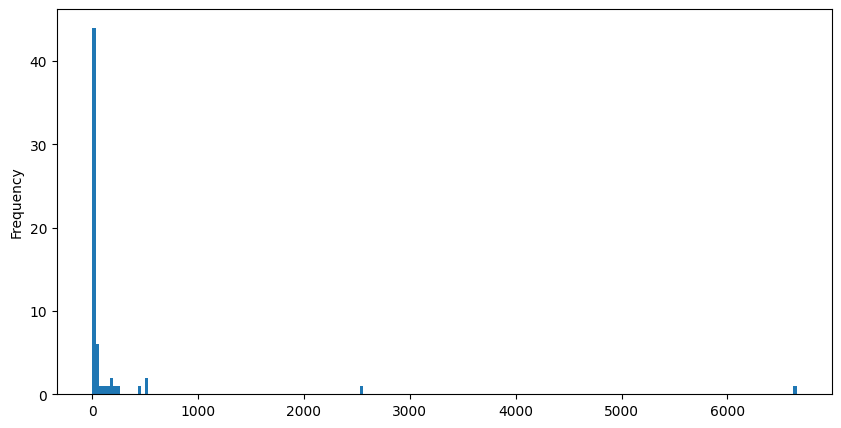

In [9]:
poids.plot.hist(bins=200, figsize=(10,5))


5. Quels sont les (deux?) animaux dont le poids semble significativement supérieur aux autres?

In [10]:
df[["Species", "Body.Weight"]][ df["Body.Weight"]> 500]

,Species,Body.Weight
0,African elephant,6654.0
4,Asian elephant,2547.0
20,Giraffe,529.0
28,Horse,521.0


6. Utiliser les noms d'animaux pour indexer le Dataframe `df` puis afficher le diagramme en battons [`df.plot.bar(...)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html) des poids des animaux

<Axes: xlabel='Species'>

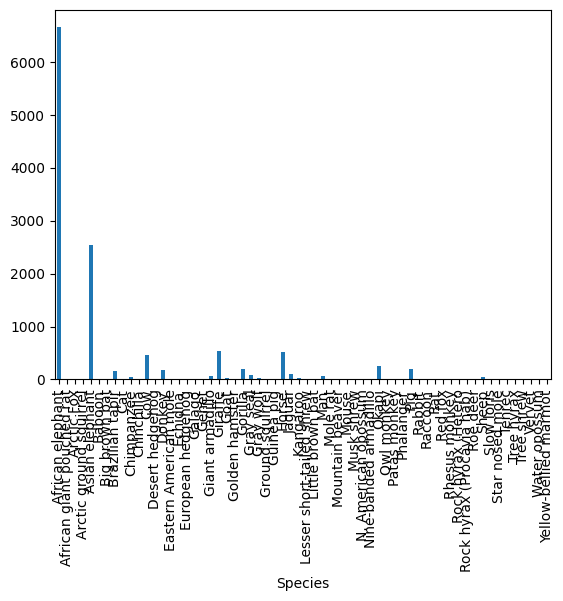

In [11]:
df = df.set_index(nom)
df.set_index(nom, inplace=True)
df["Body.Weight"].plot.bar()

7. Utiliser [`df.plot.scatter()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.scatter.html) pour imaginer un graphique susceptible de répondre à ces questions :
    - existe-t'il une correlation entre le temps de sommeil paradoxal (**Dreaming**) et le temps de sommeil total (**Sleep**)?
    - les animaux les plus exposés à la prédation durant leur sommeil (**Sleep.exposure**) sont-ils ceux qui dorment le moins? 

<Axes: xlabel='Sleep', ylabel='Dreaming'>

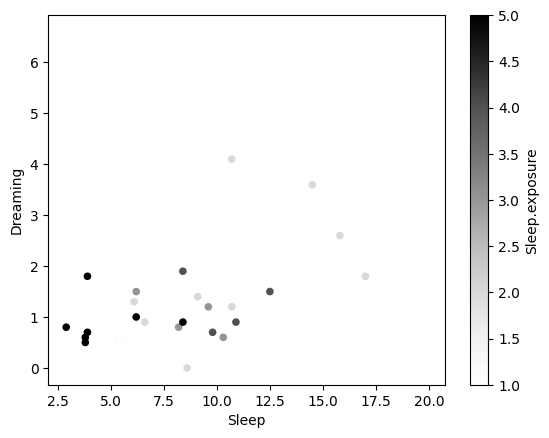

In [12]:
df.plot.scatter(x= "Sleep", y= "Dreaming", c= "Sleep.exposure")

---

## C. Quelques stats simples... mais ciblées!

La colonne `Predation` décrit chaque animal selon 5 niveaux d'exposition à la prédation (1 = plus faible exposition et 5 = plus forte exposition). Imaginons que l'on cherche à savoir combien d'animaux sont à un niveau maximal (5) d'exposition à la prédation.

Quelle instruction écririez-vous pour obtenir ce résultat? (si, vous savez faire!...)

In [13]:
val = df[["Predation"]][df["Predation"]>= 5]
count =val.count()
print(count)

Predation    14
dtype: int64


Imaginons que l'on cherche à connaître la durée moyenne de sommeil paradoxal (**Dreaming**) pour ce groupe d'animaux en particulier.
Allez-y... 

In [14]:
val = df[["Dreaming"]][df["Predation"]>= 5].mean()

print(val)


Dreaming    1.081818
dtype: float64


Imaginons (toujours!), que l'on cherche à savoir si le degré d'exposition à la prédation d'une espèce influence sa durée de sommeil paradoxal (**Dreaming**). Nous alors devoir refaire les calculs précédents pour chacun des cinq niveaux de prédation &#x1F624;



Voici une nouvelle méthode très utile en analyse des données :
- `df.value_counts(subset)` qui retourne une *Series* contenant le nombre d'observations de chaque ligne unique dans le Dataframe restreint au `subset` de colonnes

Par exemple : l'instruction `df.value_counts('Predation')` construit alors une *Series* de taille 5 contenant pour chaque niveau d'exposition, le nombre d'animaux concernés.

In [15]:
#res1= df.groupby(['Predation'], ['Sleep.exposure'])
#print(type(res))

df.value_counts("Predation").sort_index()

Predation
1    14
2    15
3    12
4     7
5    14
Name: count, dtype: int64

De même, la colonne `Sleep.exposure` contient cette fois l'indice d'exposition *durant le sommeil*. L'instruction `df.value_counts(['Predation', 'Sleep.exposure'])` construit alors une *Series* de taille au plus 25 (5x5) contenant pour chaque combinaison observée, le nombre d'animaux concernés.  

In [16]:
df.value_counts(["Predation","Sleep.exposure"]).sort_index()

Predation  Sleep.exposure
1          1                 10
           2                  2
           3                  1
           4                  1
2          1                  7
           2                  7
           3                  1
3          1                  7
           2                  2
           5                  3
4          1                  2
           3                  1
           4                  3
           5                  1
5          1                  1
           2                  2
           3                  1
           4                  1
           5                  9
Name: count, dtype: int64

> étudiez l'index de la *series* retournée par `.value_counts()` lorsqu'il y a plusieurs descripteurs... vous remarquerez que l'index d'une *Series* (et donc d'un *Dataframe*) peut être un *tuple* (index multiple)

On remarquera que les deux combinaisons les plus fréquentes correspondent aux animaux :
- soit très peu exposés : en général (1) et durant leur sommeil (1) $\rightarrow$ 10 individus
- soit très exposés : en général (5) et durant leur sommeil (5) $\rightarrow$ 9 individus


`value_counts(subset)` permet donc de constituer des *groupes* d'individus et de compter la taille de chacun des groupes. La méthode `groupby()` permet d'aller un peu plus loin en appliquant des routines statistiques sur ces *groupes* d'individus.

Ainsi l'instruction `df.groupby('Predation').mean()` renvoie un nouveau Dataframe de 5 lignes, indexé par les 5 valeurs de l'attribut `Predation`. Chaque ligne décrit alors un *groupe* d'individus selon les mêmes descripteurs qu'initialement. La méthode `mean()` utilisée ici définit la valeur qui sera calculée pour décrire le groupe selon chaque descripteur.

Revenons alors à notre question initiale : le degré d'exposition à la prédation d'une espèce influence-t'il sa durée de sommeil paradoxal (**Dreaming**)?

Predation
1    2.620000
2    2.592308
3    2.044444
4    1.200000
5    1.081818
Name: Dreaming, dtype: float64


<Axes: xlabel='Predation'>

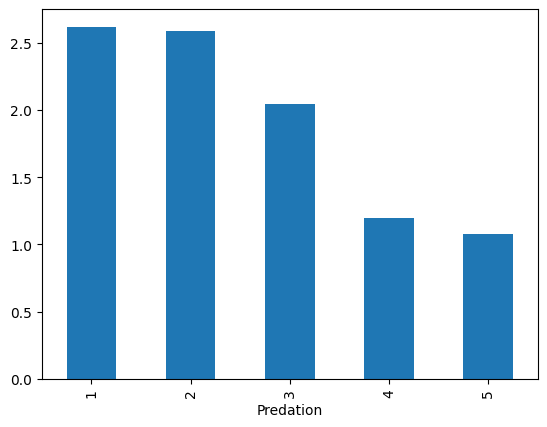

In [17]:
res= df.groupby("Predation")['Dreaming'].mean()
print(res)
res.plot.bar()

---

## D. Des requêtes avancées

### Exercice 2 : de gros dormeurs qui ne devraient peut-être pas...

1. Commencez par restreindre votre Dataframe aux descripteurs suivants :
- `Sleep` : durée de sommeil quotidien
- `Predation` : indice d'exposition à la prédation (en général)
- `Sleep.exposure` : indice d'exposition à la prédation durant le sommeil
- `Endangered` : indice d'extinction (espèce en voie de disparition)

In [19]:
df2= df[["Sleep", "Predation",  "Sleep.exposure", "Endangered"]]
df2

,Sleep,Predation,Sleep.exposure,Endangered
Species,,,,
African elephant,3.3,3,5,3
African giant pouched rat,8.3,3,1,3
Arctic Fox,12.5,1,1,1
Arctic ground squirrel,16.5,5,2,3
Asian elephant,3.9,3,5,4
...,...,...,...,...
Tree hyrax,5.4,3,1,3
Tree shrew,15.8,3,2,2
Vervet,10.3,4,3,4


2. Dans ce Dataframe, il y a 4 espèces dont la durée de sommeil n'est pas donnée (valeurs manquantes). Utilisez la méthode [`.isna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html?highlight=isna#pandas.DataFrame.isna) pour les identifier puis la méthode [`.dropna(`*axis*`)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html?highlight=dropna#pandas.DataFrame.dropna) pour les supprimer

In [20]:
df2.dropna(axis=0, inplace=True)
df2.describe()

C:\Users\asmah\AppData\Local\Temp\ipykernel_26500\3404493886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.dropna(axis=0, inplace=True)


,Sleep,Predation,Sleep.exposure,Endangered
count,58.000000,58.000000,58.000000,58.000000
mean,10.532759,2.793103,2.310345,2.534483
std,4.606760,1.472063,1.535623,1.391900
min,2.600000,1.000000,1.000000,1.000000
25%,8.050000,2.000000,1.000000,1.000000
50%,10.450000,2.500000,2.000000,2.000000
75%,13.200000,4.000000,3.750000,4.000000
max,19.900000,5.000000,5.000000,5.000000


3. Affichez les animaux qui dorment plus de 10 heures par jour

In [21]:
df2[df2["Sleep"]>10]

,Sleep,Predation,Sleep.exposure,Endangered
Species,,,,
Arctic Fox,12.5,1,1,1
Arctic ground squirrel,16.5,5,2,3
Big brown bat,19.7,1,1,1
Cat,14.5,1,2,1
Chinchilla,12.5,5,4,4
Desert hedgehog,10.3,2,1,2
European hedgehog,10.7,2,2,2
Galago,10.7,2,2,2
Giant armadillo,18.1,1,1,1


4. Affichez les "gros dormeurs" c'est-à-dire les animaux qui dorment plus que l'Homme (`Man`)

In [26]:
gros_dormeurs = df2[df2.Sleep> df2.Sleep["Man"]]

5. Affichez le nombre de "gros dormeurs" pour chaque niveau d'exposition à la prédation (**Predation**)

In [27]:
gros_dormeurs.groupby("Predation").count()

,Sleep,Sleep.exposure,Endangered
Predation,,,
1,11,11,11
2,14,14,14
3,6,6,6
4,6,6,6
5,6,6,6


6. Affichez le nombre de "gros dormeurs" en voie de disparition (**Endangered**>3) pour chaque niveau d'exposition à la prédation (**Predation**)

In [28]:
df_dormeurs_endanger = gros_dormeurs[gros_dormeurs["Endangered"]>3].groupby("Predation").count()

7. Affichez le nombre de "gros dormeurs" en voie de disparition (**Endangered**>3) pour chaque combinaison de niveau d'exposition à la prédation en général et durant le sommeil (**Predation** et **Sleep.exposure**)

In [32]:
df_dormeurs_endanger_expose = gros_dormeurs[gros_dormeurs["Endangered"]>3].groupby(["Predation", "Sleep.exposure"]).count()

8. D'après cette analyse, identifiez le(s) gros dormeur(s) qui ne devraient pas l'être? Et ceux qui ont tout intérêt à l'être?

In [41]:
(df_dormeurs_endanger_expose.Predation == 5) & (df_dormeurs_endanger_expose["Sleep.exposure"] == 5)


AttributeError: 'DataFrame' object has no attribute 'Predation'

---

## E. Deux méthodes bien utiles : .iloc() et .loc()

Au risque de se répéter, un Dataframe n'est pas un tableau NumPy! De fait, dans un Dataframe il n'est pas possible d'utiliser la double indexation `df[num. lignes, num. colonnes]` comme nous avons appris à le faire pour un tableau NumPy, bien qu'il serait parfois pratique de pouvoir le faire...

La méthode `.iloc()` a été prévue pour cela. Ainsi il sera possible de sléctionner une vue d'un Dataframe `df` à partir des indices entiers des lignes et des colonnes par l'instruction `df.iloc[num. lignes, num. colonnes]`.

De même, la méthode `.loc()`permet de sélectionner une vue d'un Dataframe `df` à partir des noms des lignes et des noms des colonnes par l'instruction `df.loc[noms lignes, noms colonnes]`.

Par exemple, l'instruction `df.iloc[0, 0]` renvoie la valeur du premier individu sur le premier descripteur :

In [ ]:
df.iloc[0,0]

'African elephant'

L'instruction `df.iloc[:10, -3:]` renvoie les valeurs des 10 premiers individus sur les 3 derniers descripteurs :

In [35]:
df.iloc[:10, -3:]

,Predation,Sleep.exposure,Endangered
Species,,,
African elephant,3,5,3
African giant pouched rat,3,1,3
Arctic Fox,1,1,1
Arctic ground squirrel,5,2,3
Asian elephant,3,5,4
Baboon,4,4,4
Big brown bat,1,1,1
Brazilian tapir,4,5,4
Cat,1,2,1


L'instruction `df.loc['Man', 'Brain.Weight']` renvoie le poids moyen en grammes du cerveau (**Brain.Weight**) de l'Homme (**Man**):

In [ ]:
df.loc["Man", "Brain.Weight"]

L'instruction `df.loc[['Man', 'Horse'], ['Brain.Weight', 'Body.Weight']]` renvoie le poids moyen du cerveau (**Brain.Weight**) et du corps (**Body.Weight**) de l'Homme (**Man**) et du cheval (**Horse**):

In [36]:
df.loc[["Man", "Horse"], ["Brain.Weight", "Body.Weight"]]

,Brain.Weight,Body.Weight
Species,,
Man,1320.0,62.0
Horse,655.0,521.0


---

## F. Exercice d'exploration

> 
> Nous allons analyser un nouveau tableau de données répertoriant des informations sur plusieurs centaines de passagers du Titanic dont :
> - leur identité, sexe, âge
> - leur classe sur le bateau (1ère classe $\rightarrow$ 3ème classe)
> - le fait qu'ils aient ou non survécu au naufrage
> - ...

1. Chargez le jeu de données *titanic.csv* et utilisez quelques commandes de base afin de connaître le nombre d'individus, le nombre et la nature des descripteurs, les statistiques de base ainsi que les éventuelles données manquantes

In [37]:
df_titanic = pd.read_csv('donnees/titanic.csv', sep=";", header="infer")
df_titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. On ne s'intéressera qu'aux descripteurs suivants : `Pclass`, `Sex`, `Age` et `Survival`. Modifiez le Dataframe en conséquence puis supprimez les individus pour lesquels des données sont manquantes

In [38]:
df_titanic = df_titanic[["Pclass", "Sex", "Age", "Survived"]]
df_titanic.dropna(axis=0, inplace=True)
df_titanic.describe()

C:\Users\asmah\AppData\Local\Temp\ipykernel_26500\1495401874.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titanic.dropna(axis=0, inplace=True)


,Pclass,Age,Survived
count,714.000000,714.000000,714.000000
mean,2.236695,29.699118,0.406162
std,0.838250,14.526497,0.491460
min,1.000000,0.420000,0.000000
25%,1.000000,20.125000,0.000000
50%,2.000000,28.000000,0.000000
75%,3.000000,38.000000,1.000000
max,3.000000,80.000000,1.000000


3. Combien y-a-t'il eu de survivants parmi les passagers restants? Quel est le taux de survie?

In [39]:
total = df_titanic.Age.count()
print("Passager total:", total)
survivant = (df_titanic.Survived == 1).sum()
print("Passager survivant:", survivant)
taux_survie = survivant/total*100
print("Taux de survie:", taux_survie)

Passager total: 714
Passager survivant: 290
Taux de survie: 40.61624649859944


4. Les enfants ont ils été sauvés en priorité? Est-ce que la formule *les femmes et les enfants d'abord* semble avoir été repectée?

In [40]:
total_enfants = (df_titanic.Age<18).sum()
print("Total enfants : ", total_enfants)
survivants_enfants = ((df_titanic.Survived==1) & (df_titanic.Age<18)).sum()
print("Survivants enfants : ", survivants_enfants)
taux_survie_enfants = survivants_enfants/total_enfants*100
print("Taux de survie enfants : ", taux_survie_enfants)



Total enfants :  113
Survivants enfants :  61
Taux de survie enfants :  53.98230088495575


5. Une hiérarchie de classe a-t'elle joué durant le sauvetage?